In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

### Functions for Calculation Centralities

In [2]:
# Weighted Closeness Centrality
def weighted_closeness(G):
    nodes = list(G.nodes())
    closeness = []
    for i in range(0, len(nodes)):
        close = []
        dist_ij = 0
        for j in range(0, len(nodes)):
            if(nodes[i] == nodes[j]):
                    continue
            else:
                wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[i], target=nodes[j], weight='weight')
                dist_ij = dist_ij + wt
        closeness_i = 1 / dist_ij
        close.append(nodes[i])
        close.append(closeness_i)
        closeness.append(close)
    return closeness

# Weighted Betweenness Centrality
def weighted_betweenness(G):
    nodes = list(G.nodes())
    betweenness = []
    for n in range(0, len(nodes)):
        bett = []
        dist_n = 0
        dist_v = 0
        for s in range(0, len(nodes)):
            for t in range(s+1, len(nodes)):
                if(nodes[n] == nodes[s] or nodes[n] == nodes[t] or nodes[s] == nodes[t]):
                    continue
                else:
                    wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[s], target=nodes[t], weight='weight')
                    if(nodes[n] in s_path):
                        dist_n = dist_n + wt
                    dist_v = dist_v + wt
        betweenness_n = dist_n / dist_v
        bett.append(nodes[n])
        bett.append(betweenness_n)
        betweenness.append(bett)
    return betweenness

# Weighted Edge Contribution Factor
def weighted_ECF(G, W):
    nodes = list(G.nodes())
    ecf = []
    for i in range(0, len(nodes)):
        ecf_ = []
        w_ij = 0
        w_jk = 0
        neighbours_i = list(G.neighbors(nodes[i]))
        for n in range(0, len(neighbours_i)):
            w_ = G.get_edge_data(nodes[i], neighbours_i[n])
            val = w_['weight']
            w_ij = w_ij + val
        nbunch = neighbours_i
        common_neighbours = G.edges(nbunch, data=True)
        common_neighbours = list(common_neighbours)
        for j in range(0, len(common_neighbours)):
            if((common_neighbours[j][0] == nodes[i]) or (common_neighbours[j][1] == nodes[i])):
                continue
            elif(((common_neighbours[j][0] in neighbours_i) == False) or ((common_neighbours[j][1] in neighbours_i) == False )):
                continue
            else:
                w_ = G.get_edge_data(common_neighbours[j][0], common_neighbours[j][1])
                val = w_['weight']
                w_jk = w_jk + val            
            
        w_ecf = (w_ij + w_jk) / W
        ecf_.append(nodes[i])
        ecf_.append(w_ecf)
        ecf.append(ecf_)
    return ecf

def degree(G,W):
    nodes = list(G.nodes())
    w_degree = []
    for i in range(0, len(nodes)):
        deg = []
        nd = nodes[i]
        m_dg = modi_deg(G,nd,W)
        deg.append(nd)
        deg.append(m_dg)
        w_degree.append(deg)
    return w_degree

# New One
def modi_deg(G,i,W_):
    d_i = G.degree(i, weight='weight')
    m_deg = (d_i/W_)/2
    return m_deg

def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    m_deg = modi_deg(G,i,W_1)
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    weight_value = value * m_deg
    return weight_value


def weighted_cness(G, W):
    nodes = list(G.nodes())
    w_closeness = []
    for i in range(0, len(nodes)):
        closeness = []
        nd = nodes[i]
        weight = weight_of_a_node(G,nd,W)
        closeness.append(nd)
        closeness.append(weight)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_


def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### Loading Dataset and Create the Network and its Visualization

### s_m_1

Name: 
Type: Graph
Number of nodes: 10
Number of edges: 11
Average degree:   2.2000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


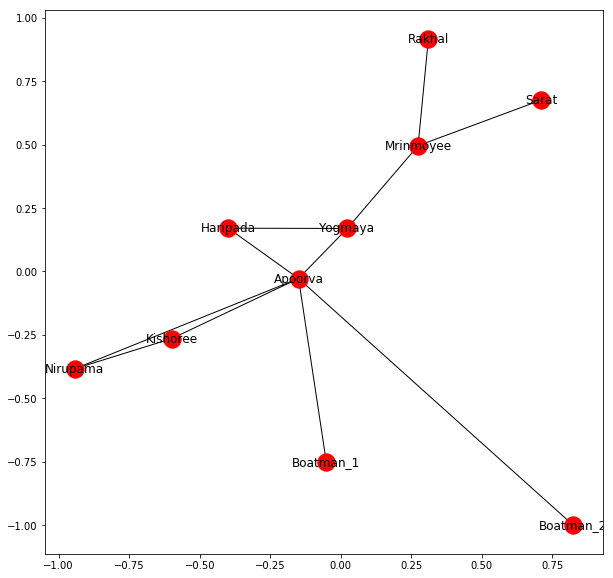

       Nodes  Degree       ECF       NCF
0    Apoorva   155.0  0.735683  0.300801
1  Boatman_1     4.0  0.017621  0.006016
2  Boatman_2     1.0  0.004405  0.001504
3    Yogmaya   143.0  0.748899  0.299715
4   Haripada    28.0  0.603524  0.051350
5   Nirupama    13.0  0.110132  0.020940
6   Kishoree    23.0  0.110132  0.037047
7  Mrinmoyee    60.0  0.264317  0.098973
8      Sarat    12.0  0.052863  0.006986
9     Rakhal    15.0  0.066079  0.008733
     Degree       ECF       NCF
0  0.693583  0.587526  0.681675
1  0.017899  0.014072  0.013634
2  0.004475  0.003518  0.003408
3  0.639887  0.598080  0.679212
4  0.125292  0.481982  0.116369
5  0.058172  0.087953  0.047453
6  0.102919  0.087953  0.083956
7  0.268484  0.211087  0.224293
8  0.053697  0.042217  0.015832
9  0.067121  0.052772  0.019791


In [3]:
sm_1 = nx.read_weighted_edgelist('s_m_1.txt', delimiter=',')
print(nx.info(sm_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_1)
plt.show()

#Weighted Centralities
w_deg = sm_1.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(sm_1)  #ECF
w_ecf = weighted_ECF(sm_1, total_edge_weight)

total_edge_weight = total_weight_of_G(sm_1) #NCF
w_ncf = weighted_cness(sm_1,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [4]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.694,0.588,0.682
1,0.018,0.014,0.014
2,0.004,0.004,0.003
3,0.640,0.598,0.679
4,0.125,0.482,0.116
5,0.058,0.088,0.047
6,0.103,0.088,0.084
7,0.268,0.211,0.224
8,0.054,0.042,0.016
9,0.067,0.053,0.020


Text(0, 0.5, 'Values')

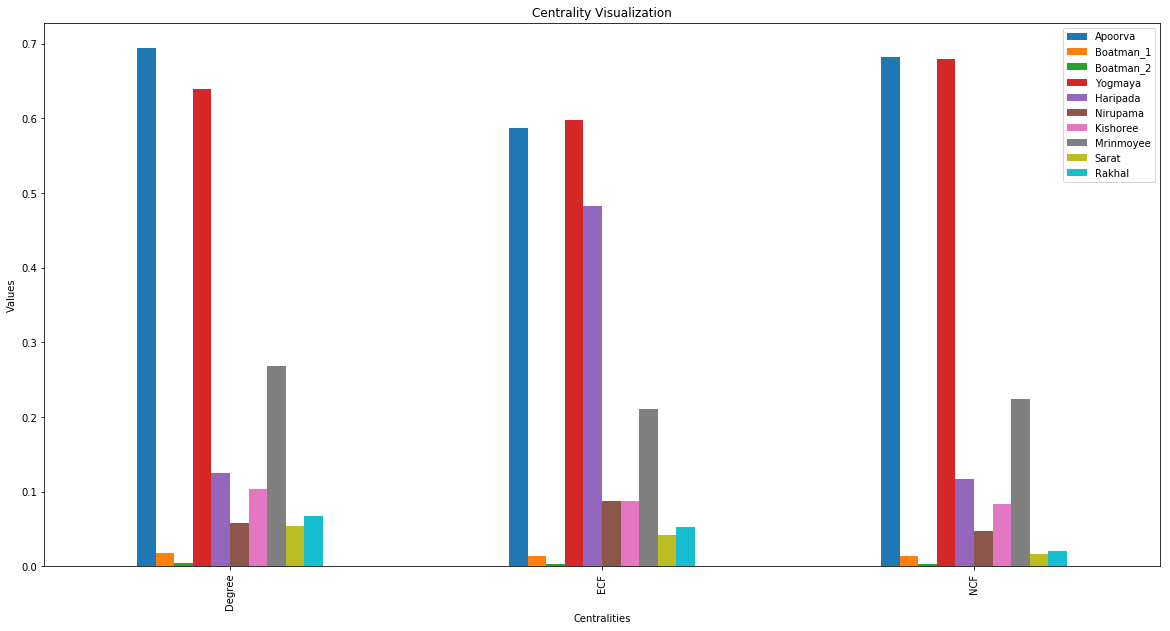

In [5]:
plotdata = pd.DataFrame({

    "Apoorva":list(df_2.loc[0]),

    "Boatman_1":list(df_2.loc[1]),

    "Boatman_2":list(df_2.loc[2]),
    "Yogmaya":list(df_2.loc[3]),
    
    "Haripada":list(df_2.loc[4]),
    
    "Nirupama":list(df_2.loc[5]),
    
    "Kishoree":list(df_2.loc[6]),
    "Mrinmoyee":list(df_2.loc[7]),
    "Sarat":list(df_2.loc[8]),
    "Rakhal":list(df_2.loc[9])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(20, 10))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

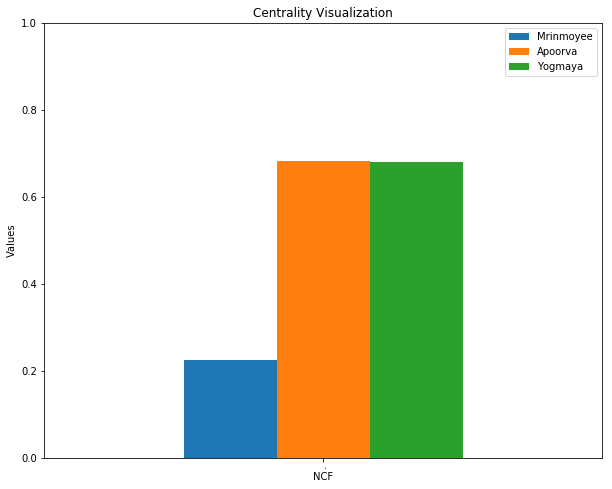

In [6]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[7][2],
    "Apoorva":df_2.loc[0][2],
    "Yogmaya":df_2.loc[3][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

### s_m_2

Name: 
Type: Graph
Number of nodes: 11
Number of edges: 13
Average degree:   2.3636


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


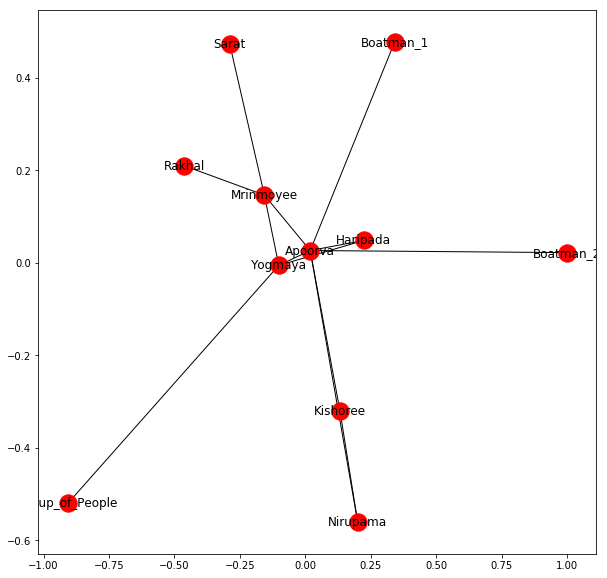

              Nodes  Degree       ECF       NCF
0           Apoorva   220.0  0.906040  0.369128
1         Boatman_1     4.0  0.013423  0.004955
2         Boatman_2     1.0  0.003356  0.001239
3           Yogmaya   152.0  0.808725  0.245620
4          Haripada    30.0  0.476510  0.043917
5          Nirupama    13.0  0.083893  0.016908
6          Kishoree    23.0  0.083893  0.029914
7         Mrinmoyee   125.0  0.795302  0.201990
8             Sarat    12.0  0.040268  0.008446
9            Rakhal    15.0  0.050336  0.010557
10  Group_of_People     1.0  0.003356  0.000856
      Degree       ECF       NCF
0   0.736970  0.590665  0.752377
1   0.013399  0.008751  0.010099
2   0.003350  0.002188  0.002525
3   0.509179  0.527224  0.500636
4   0.100496  0.310646  0.089514
5   0.043548  0.054691  0.034463
6   0.077047  0.054691  0.060973
7   0.418733  0.518473  0.411707
8   0.040198  0.026252  0.017214
9   0.050248  0.032815  0.021518
10  0.003350  0.002188  0.001744


In [7]:
sm_2 = nx.read_weighted_edgelist('s_m_2.txt', delimiter=',')
print(nx.info(sm_2))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_2)
plt.show()

#Weighted Centralities
w_deg = sm_2.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(sm_2)  #ECF
w_ecf = weighted_ECF(sm_2, total_edge_weight)

total_edge_weight = total_weight_of_G(sm_2) #NCF
w_ncf = weighted_cness(sm_2,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [8]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.737,0.591,0.752
1,0.013,0.009,0.010
2,0.003,0.002,0.003
3,0.509,0.527,0.501
4,0.100,0.311,0.090
5,0.044,0.055,0.034
6,0.077,0.055,0.061
7,0.419,0.518,0.412
8,0.040,0.026,0.017
9,0.050,0.033,0.022


Text(0, 0.5, 'Values')

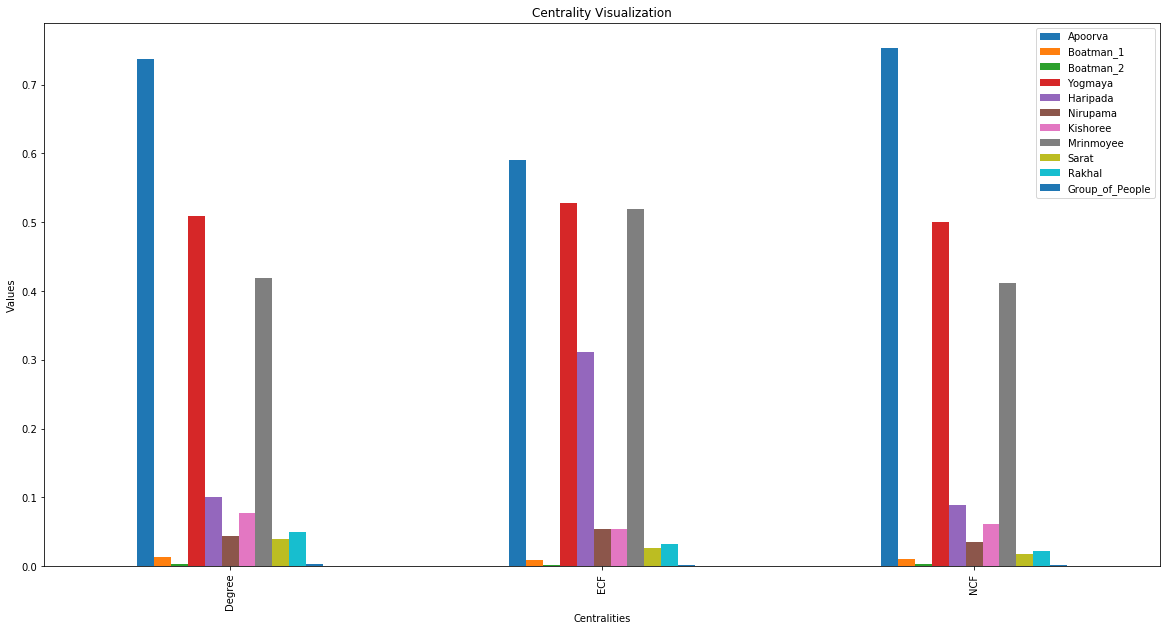

In [9]:
plotdata = pd.DataFrame({

    "Apoorva":list(df_2.loc[0]),

    "Boatman_1":list(df_2.loc[1]),

    "Boatman_2":list(df_2.loc[2]),
    "Yogmaya":list(df_2.loc[3]),
    
    "Haripada":list(df_2.loc[4]),
    
    "Nirupama":list(df_2.loc[5]),
    
    "Kishoree":list(df_2.loc[6]),
    "Mrinmoyee":list(df_2.loc[7]),
    "Sarat":list(df_2.loc[8]),
    "Rakhal":list(df_2.loc[9]),
    "Group_of_People":list(df_2.loc[10])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(20, 10))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

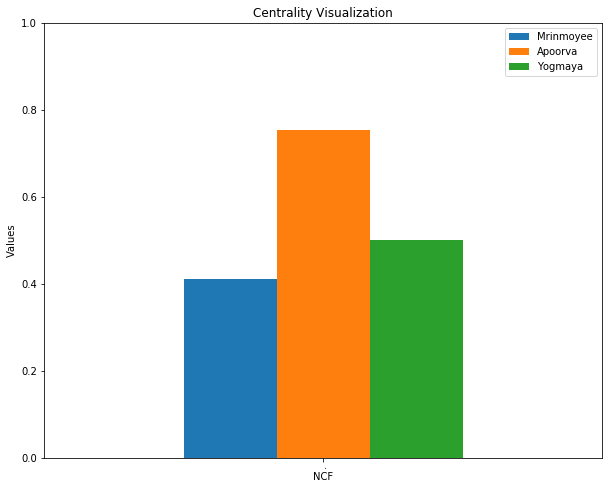

In [10]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[7][2],
    "Apoorva":df_2.loc[0][2],
    "Yogmaya":df_2.loc[3][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

### s_m_3

Name: 
Type: Graph
Number of nodes: 11
Number of edges: 13
Average degree:   2.3636


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


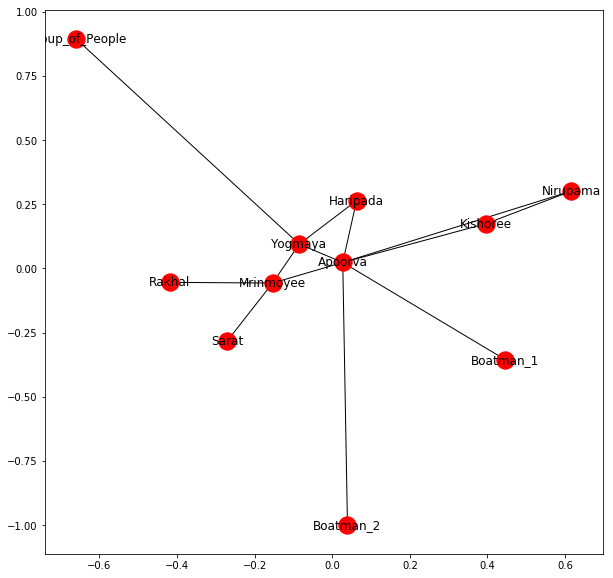

              Nodes  Degree       ECF       NCF
0           Apoorva   246.0  0.843305  0.350427
1         Boatman_1     4.0  0.011396  0.003993
2         Boatman_2     1.0  0.002849  0.000998
3           Yogmaya   152.0  0.760684  0.209739
4          Haripada    30.0  0.404558  0.034821
5          Nirupama    13.0  0.071225  0.013559
6          Kishoree    23.0  0.071225  0.023989
7         Mrinmoyee   178.0  0.826211  0.245615
8             Sarat    26.0  0.074074  0.018782
9            Rakhal    28.0  0.079772  0.020227
10  Group_of_People     1.0  0.002849  0.000617
      Degree       ECF       NCF
0   0.714983  0.574031  0.730902
1   0.011626  0.007757  0.008329
2   0.002906  0.001939  0.002082
3   0.441778  0.517791  0.437461
4   0.087193  0.275380  0.072628
5   0.037784  0.048482  0.028281
6   0.066848  0.048482  0.050035
7   0.517346  0.562395  0.512290
8   0.075567  0.050422  0.039175
9   0.081380  0.054300  0.042189
10  0.002906  0.001939  0.001287


In [11]:
sm_3 = nx.read_weighted_edgelist('s_m_3.txt', delimiter=',')
print(nx.info(sm_3))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_3)
plt.show()

#Weighted Centralities
w_deg = sm_3.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(sm_3)  #ECF
w_ecf = weighted_ECF(sm_3, total_edge_weight)

total_edge_weight = total_weight_of_G(sm_3) #NCF
w_ncf = weighted_cness(sm_3,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [12]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.715,0.574,0.731
1,0.012,0.008,0.008
2,0.003,0.002,0.002
3,0.442,0.518,0.437
4,0.087,0.275,0.073
5,0.038,0.048,0.028
6,0.067,0.048,0.050
7,0.517,0.562,0.512
8,0.076,0.050,0.039
9,0.081,0.054,0.042


Text(0, 0.5, 'Values')

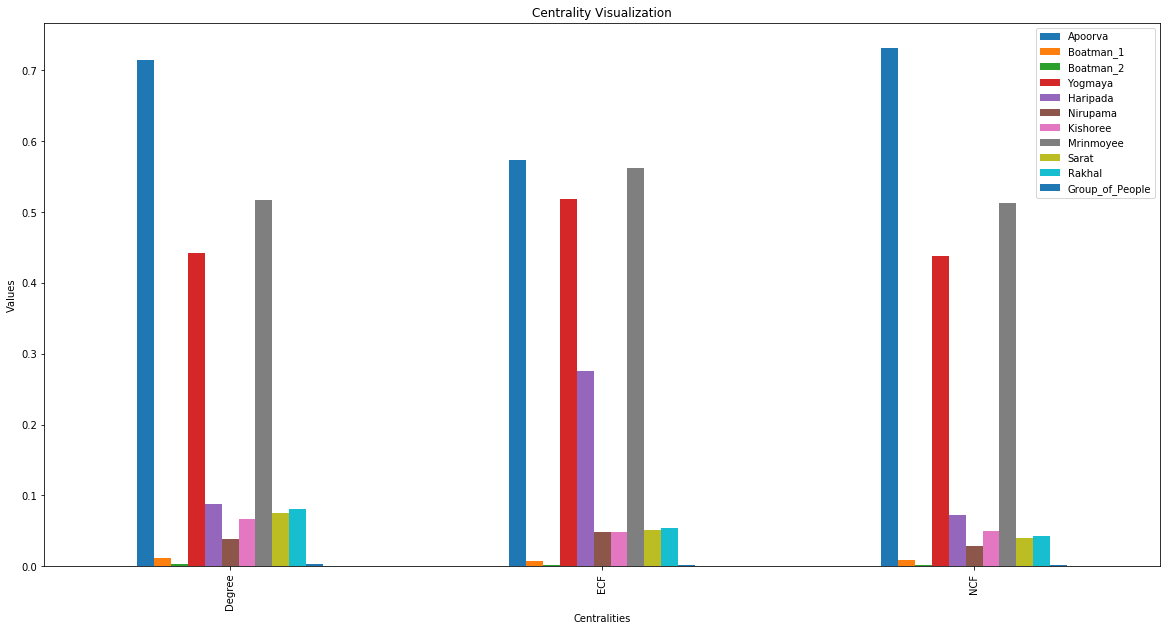

In [13]:
plotdata = pd.DataFrame({

    "Apoorva":list(df_2.loc[0]),

    "Boatman_1":list(df_2.loc[1]),

    "Boatman_2":list(df_2.loc[2]),
    "Yogmaya":list(df_2.loc[3]),
    
    "Haripada":list(df_2.loc[4]),
    
    "Nirupama":list(df_2.loc[5]),
    
    "Kishoree":list(df_2.loc[6]),
    "Mrinmoyee":list(df_2.loc[7]),
    "Sarat":list(df_2.loc[8]),
    "Rakhal":list(df_2.loc[9]),
    "Group_of_People":list(df_2.loc[10])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(20, 10))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

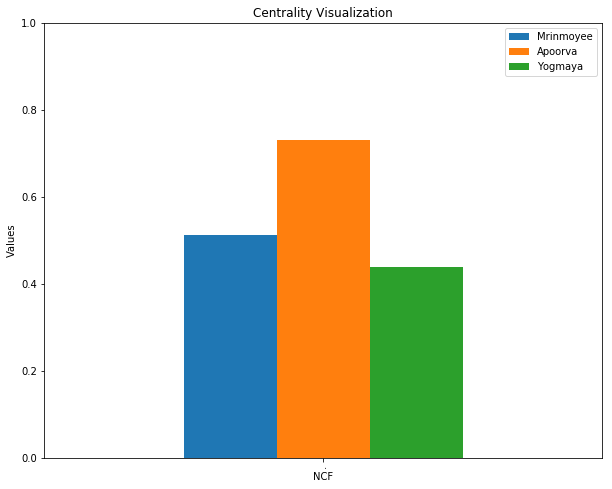

In [14]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[7][2],
    "Apoorva":df_2.loc[0][2],
    "Yogmaya":df_2.loc[3][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

### s_m_4

Name: 
Type: Graph
Number of nodes: 12
Number of edges: 16
Average degree:   2.6667


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


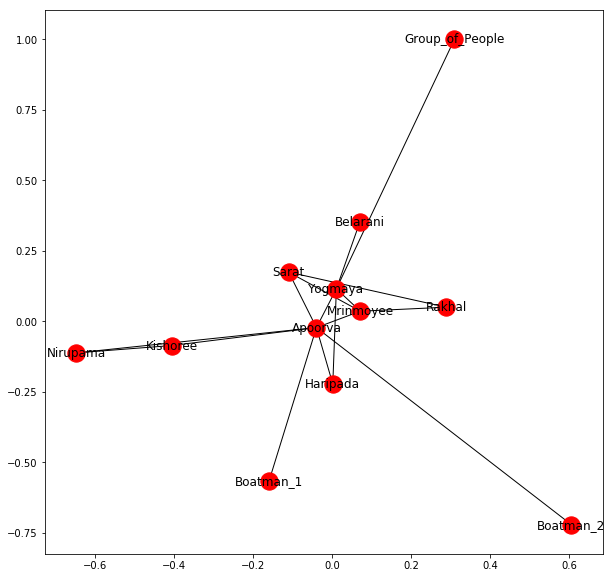

              Nodes  Degree       ECF       NCF
0           Apoorva   317.0  0.852495  0.343818
1         Boatman_1     4.0  0.008677  0.002983
2         Boatman_2     1.0  0.002169  0.000746
3           Yogmaya   231.0  0.780911  0.244021
4          Haripada    30.0  0.412148  0.027386
5          Nirupama    13.0  0.054230  0.010032
6          Kishoree    23.0  0.054230  0.017749
7         Mrinmoyee   199.0  0.800434  0.210685
8             Sarat    36.0  0.375271  0.035149
9            Rakhal    36.0  0.134490  0.017702
10  Group_of_People     1.0  0.002169  0.000543
11         Belarani    31.0  0.067245  0.016848
      Degree       ECF       NCF
0   0.711292  0.560109  0.724585
1   0.008975  0.005701  0.006287
2   0.002244  0.001425  0.001572
3   0.518323  0.513077  0.514266
4   0.067315  0.270790  0.057714
5   0.029170  0.035630  0.021142
6   0.051608  0.035630  0.037405
7   0.446521  0.525904  0.444012
8   0.080778  0.246562  0.074076
9   0.080778  0.088363  0.037306
10  0.002244 

In [15]:
sm_4 = nx.read_weighted_edgelist('s_m_4.txt', delimiter=',')
print(nx.info(sm_4))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_4)
plt.show()

#Weighted Centralities
w_deg = sm_4.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(sm_4)  #ECF
w_ecf = weighted_ECF(sm_4, total_edge_weight)

total_edge_weight = total_weight_of_G(sm_4) #NCF
w_ncf = weighted_cness(sm_4,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [16]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.711,0.560,0.725
1,0.009,0.006,0.006
2,0.002,0.001,0.002
3,0.518,0.513,0.514
4,0.067,0.271,0.058
5,0.029,0.036,0.021
6,0.052,0.036,0.037
7,0.447,0.526,0.444
8,0.081,0.247,0.074
9,0.081,0.088,0.037


Text(0, 0.5, 'Values')

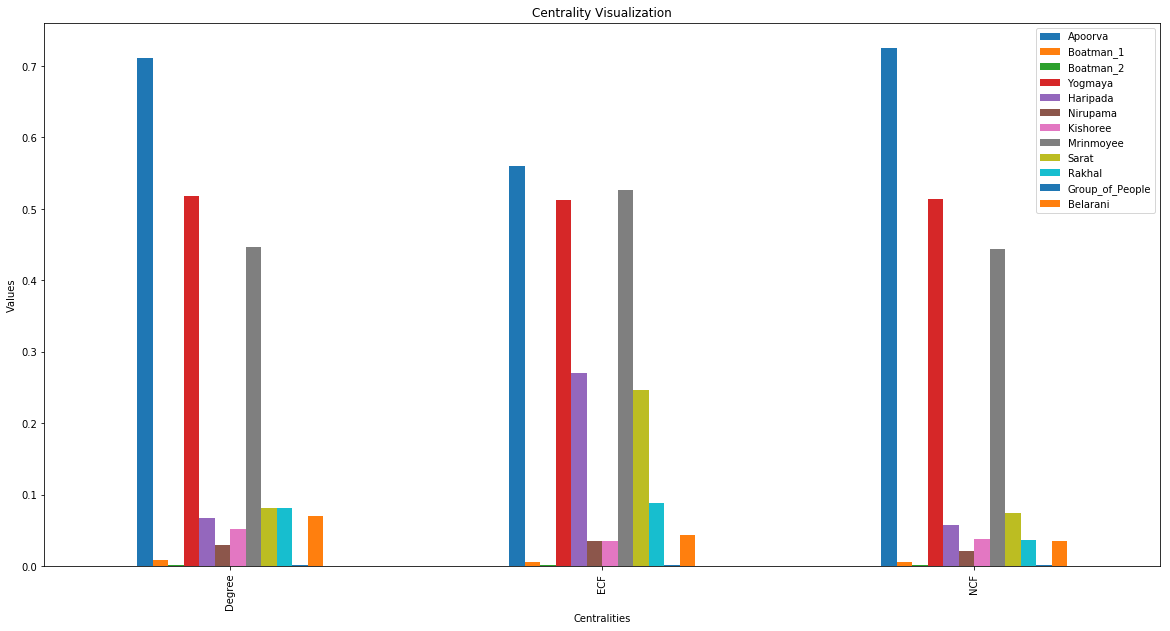

In [17]:
plotdata = pd.DataFrame({

    "Apoorva":list(df_2.loc[0]),

    "Boatman_1":list(df_2.loc[1]),

    "Boatman_2":list(df_2.loc[2]),
    "Yogmaya":list(df_2.loc[3]),
    
    "Haripada":list(df_2.loc[4]),
    
    "Nirupama":list(df_2.loc[5]),
    
    "Kishoree":list(df_2.loc[6]),
    "Mrinmoyee":list(df_2.loc[7]),
    "Sarat":list(df_2.loc[8]),
    "Rakhal":list(df_2.loc[9]),
    "Group_of_People":list(df_2.loc[10]),
    "Belarani":list(df_2.loc[11])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(20, 10))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

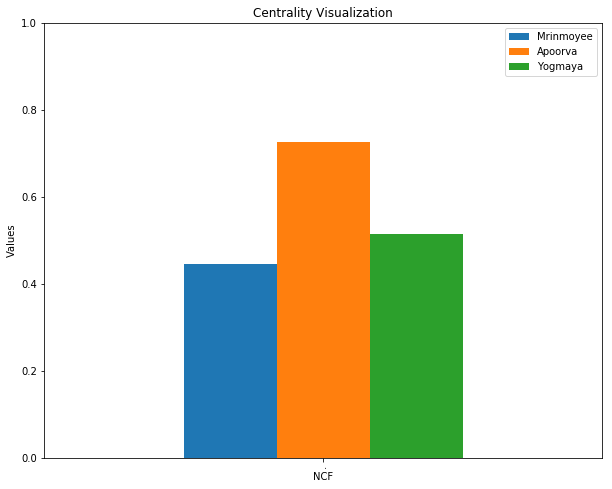

In [18]:
plotdata = pd.DataFrame({

    "Mrinmoyee":df_2.loc[7][2],
    "Apoorva":df_2.loc[0][2],
    "Yogmaya":df_2.loc[3][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("Centrality Visualization")

plt.xlabel("NCF")

plt.ylabel("Values")

In [19]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4']

apoorva = [0.681675,0.752377,0.730902,0.724585]

yogmaya = [0.679212,0.500636,0.437461,0.514266]
mrinmoyee = [0.224293,0.411707,0.512290,0.444012]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Apoorva' : apoorva,'Yogmaya' : yogmaya, 'Mrinmoyee' : mrinmoyee})

df_pop_density

,Timestamp,Apoorva,Yogmaya,Mrinmoyee
0,t1,0.681675,0.679212,0.224293
1,t2,0.752377,0.500636,0.411707
2,t3,0.730902,0.437461,0.512290
3,t4,0.724585,0.514266,0.444012


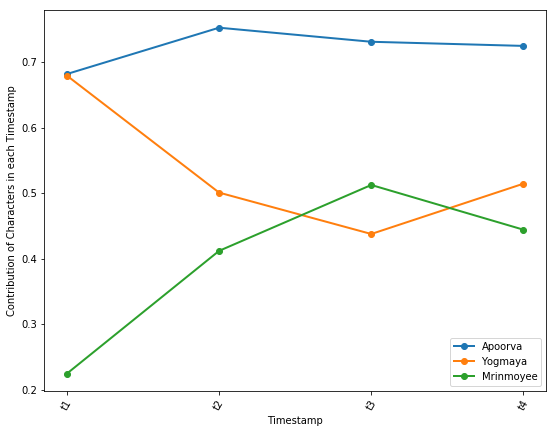

In [20]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[9, 7])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Apoorva'], marker='o', linewidth=2, label='Apoorva')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Yogmaya'], marker='o', linewidth=2, label='Yogmaya')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Mrinmoyee'], marker='o', linewidth=2, label='Mrinmoyee')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Contribution of Characters in each Timestamp')
plt.legend()
plt.show()

In [ ]:
# Reevaluate to calculate the correlation

In [45]:
print('Correlation of Mrinmoyee and Apoorva is', correlation(sm_4,'Apoorva','Mrinmoyee'))

Correlation of Mrinmoyee and Apoorva is 0.704532124344118


In [51]:
print('Correlation of Yogmaya and Apoorva is', correlation(sm_4,'Apoorva','Yogmaya'))

Correlation of Yogmaya and Apoorva is 0.7853797096699305


In [52]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4']

apoorva_yogmaya = [0.674937965260546,0.9076255980861245,0.9166934103551562,0.7853797096699305]

apoorva_mrinmoyee = [0,0.6200727272727273,0.5663652142139399,0.704532124344118]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Correlation_With_Yogmaya' : apoorva_yogmaya, 'Correlation_With_Mrinmoyee' : apoorva_mrinmoyee})

df_pop_density

,Timestamp,Correlation_With_Yogmaya,Correlation_With_Mrinmoyee
0,t1,0.674938,0.000000
1,t2,0.907626,0.620073
2,t3,0.916693,0.566365
3,t4,0.785380,0.704532


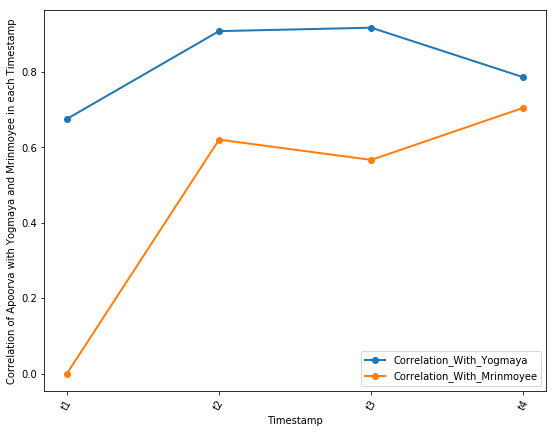

In [53]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[9, 7])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Yogmaya'], marker='o', linewidth=2, label='Correlation_With_Yogmaya')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Mrinmoyee'], marker='o', linewidth=2, label='Correlation_With_Mrinmoyee')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Correlation of Apoorva with Yogmaya and Mrinmoyee in each Timestamp')
plt.legend()
plt.show()

In [ ]:
# Weighted Closeness Centrality
def weighted_closeness(G):
    nodes = list(G.nodes())
    closeness = []
    for i in range(0, len(nodes)):
        close = []
        dist_ij = 0
        for j in range(0, len(nodes)):
            if(nodes[i] == nodes[j]):
                    continue
            else:
                wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[i], target=nodes[j], weight='weight')
                dist_ij = dist_ij + wt
        closeness_i = 1 / dist_ij
        close.append(nodes[i])
        close.append(closeness_i)
        closeness.append(close)
    return closeness

# Weighted Betweenness Centrality
def weighted_betweenness(G):
    nodes = list(G.nodes())
    betweenness = []
    for n in range(0, len(nodes)):
        bett = []
        dist_n = 0
        dist_v = 0
        for s in range(0, len(nodes)):
            for t in range(s+1, len(nodes)):
                if(nodes[n] == nodes[s] or nodes[n] == nodes[t] or nodes[s] == nodes[t]):
                    continue
                else:
                    wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[s], target=nodes[t], weight='weight')
                    if(nodes[n] in s_path):
                        dist_n = dist_n + wt
                    dist_v = dist_v + wt
        betweenness_n = dist_n / dist_v
        bett.append(nodes[n])
        bett.append(betweenness_n)
        betweenness.append(bett)
    return betweenness

# Weighted Edge Contribution Factor
def weighted_ECF(G, W):
    nodes = list(G.nodes())
    ecf = []
    for i in range(0, len(nodes)):
        ecf_ = []
        w_ij = 0
        w_jk = 0
        neighbours_i = list(G.neighbors(nodes[i]))
        for n in range(0, len(neighbours_i)):
            w_ = G.get_edge_data(nodes[i], neighbours_i[n])
            val = w_['weight']
            w_ij = w_ij + val
        nbunch = neighbours_i
        common_neighbours = G.edges(nbunch, data=True)
        common_neighbours = list(common_neighbours)
        for j in range(0, len(common_neighbours)):
            if((common_neighbours[j][0] == nodes[i]) or (common_neighbours[j][1] == nodes[i])):
                continue
            elif(((common_neighbours[j][0] in neighbours_i) == False) or ((common_neighbours[j][1] in neighbours_i) == False )):
                continue
            else:
                w_ = G.get_edge_data(common_neighbours[j][0], common_neighbours[j][1])
                val = w_['weight']
                w_jk = w_jk + val            
            
        w_ecf = (w_ij + w_jk) / W
        ecf_.append(nodes[i])
        ecf_.append(w_ecf)
        ecf.append(ecf_)
    return ecf

# Weighted Closeness New
def weighted_cness(G, W):
    nodes = list(G.nodes())
    w_closeness = []
    for i in range(0, len(nodes)):
        closeness = []
        w_ij = 0
        neighbours_i = list(G.neighbors(nodes[i]))
        for j in range(0, len(neighbours_i)):
            w_ = G.get_edge_data(nodes[i], neighbours_i[j])
            val = w_['weight']
            deg_j = list(G.degree([neighbours_i[j]], weight='weight'))
            w_ij_deg_j = val / deg_j[0][1]
            w_ij = w_ij + w_ij_deg_j
        d_i = list(G.degree([nodes[i]], weight='weight'))
        deg_i = d_i[0][1]
        w_cness = (deg_i + w_ij) / W
        closeness.append(nodes[i])
        closeness.append(w_cness)
        w_closeness.append(closeness)
    return w_closeness

# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_


def convert_to_list_value(lst):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][1]
        l.append(val)
    return l

def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

def correlation(G,i,j):
    d_i = G.degree(i, weight='weight')
    d_j = G.degree(j, weight='weight')
    w_ic = 0
    w_jc = 0
    w_ = G.get_edge_data(i, j)
    if(w_ == None):
        w_ij = 0
    else:
        w_ij = w_['weight']
    common_nbr = intersection(list(G.neighbors(i)),list(G.neighbors(j)))
    if(w_ij == 0):
        print("The correlation is 0.")
    elif((w_ij != 0) and (len(common_nbr) == 0)):
        corr = ((w_ij + w_ic) / d_i) * ((w_ij + w_jc) / d_j)
        return corr
    else:
        for k in range(len(common_nbr)):
            w_i = G.get_edge_data(i, common_nbr[k])
            val = w_i['weight']
            w_ic = w_ic + val
        
        for l in range(len(common_nbr)):
            w_j = G.get_edge_data(j, common_nbr[l])
            val = w_j['weight']
            w_jc = w_jc + val
        
        corr = ((w_ij + w_ic) / d_i) * ((w_ij + w_jc) / d_j)
        return corr